# Example 1
CN：在菱形ABCD中，过点A作AE⊥CD，垂足E在CD的延长线上，过点E作EF⊥BC，垂足为F。AE=3，EF=4。  

EN: In rhombus ABCD, a line is drawn from point A such that AE is perpendicular to CD, with point E lying on the extension of CD. Then, from point E, a line EF is drawn perpendicular to BC, with the foot of the perpendicular being F. If AE equals 3, and EF equals 4, then the length of the side of the rhombus is ___.

Objective function value: 2.2236e-13 | Status: success

Equality constraints (should be ≈ 0):
--------------------------------------------------------------------------------------
Name                                     Equation                              Value   
--------------------------------------------------------------------------------------
LineSegment_A_B || LineSegment_C_D (cros (-A_x + B_x)*(-C_y + D_y) - (-  -8.9167e-08  ✅
LineSegment_B_C || LineSegment_D_A (cros -(A_x - D_x)*(-B_y + C_y) + (A  -1.4845e-07  ✅
Rhombus: Rhombus_A_B_C_D a=b             sqrt((A_x - B_x)**2 + (A_y - B   4.4905e-08  ✅
Rhombus: Rhombus_A_B_C_D b=c             sqrt((B_x - C_x)**2 + (B_y - C   1.4485e-08  ✅
Rhombus: Rhombus_A_B_C_D c=d             -sqrt((-A_x + D_x)**2 + (-A_y   -6.0702e-08  ✅
Rhombus: Rhombus_A_B_C_D a=d             sqrt((-A_x + D_x)**2 + (-A_y +   1.3119e-09  ✅
LineSegment_A_E ⟂ LineSegment_C_D (dot p (-A_x + E_x)*(-C_x + D_x) + (-  -8.0324e-09  ✅
C, D, E collinear           

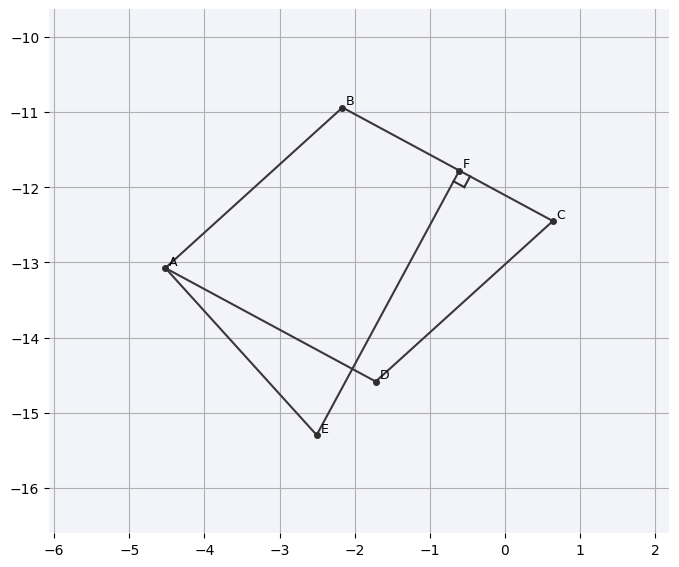

In [2]:
from pygeox import GeoScene, LineSegment

scene = GeoScene()

A, B, C, D, E, F = scene.add.points(["A", "B", "C", "D", "E", "F"])

# 菱形ABCD; in rhombus ABCD
rhombus = scene.add.rhombus(A, B, C, D)

# 过点A作AE⊥CD; a line is drawn from point A such that AE is perpendicular to CD
line_AE = scene.add.line_segment(A, E)
scene.relate.perpendicular(line_AE, LineSegment(C,D))

# 垂足E在CD的延长线上; with point E lying on the extension of CD
scene.relate.collinear(C, D, E)

# 过点E作EF⊥BC 垂足为F; from point E, a line EF is drawn perpendicular to BC with the foot of the perpendicular being F
line_EF = scene.add.line_segment(E, F)
scene.relate.perpendicular(line_EF, LineSegment(B,C), foot = F)

## AE=3，EF=4
scene.constraint.eq(line_AE.length, 3)
scene.constraint.eq(line_EF.length, 4)

scene.solver.numerical()
scene.plot()

In [3]:
scene.solver.status

'success'

In [3]:
rhombus.sides[0].length.evalf(4)

3.182

In [5]:
#no copy feature
circle_r = {str(val.center.name):val.radius for val in scene.objects_solved["Circle"].values()}
scene.solver._internal_sol  - scene.solver.get_internal_vals(scene.get_points(),circle_r)

['A_x', 'A_y', 'B_x', 'B_y', 'C_x', 'C_y', 'D_x', 'D_y', 'E_x', 'E_y', 'F_x', 'F_y']
['A_x', 'A_y', 'B_x', 'B_y', 'C_x', 'C_y', 'D_x', 'D_y', 'E_x', 'E_y', 'F_x', 'F_y']


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

# Example 2
CN: 在正六边形 ABCDEF 中，经过点 E，F 的⊙O 与边 AB，CD 分别相切于点 G，H，与边 DE 交于点 M，连接 GM，FH 交于点 N，则∠GNF 的度数为___°.  

EN: In a regular hexagon ABCDEF, a circle ⊙O passing through points E and F is tangent to sides AB and CD at points G and H, respectively, and intersects side DE at point M. Lines GM and FH intersect at point N, the measure of angle ∠GNF is ___°.

[INFO] Penalty active to prevent overlapping points (min_dist=0.2). To remove add: distance_penalty = 0
Objective function value: 1.3088e-09 | Status: success

Equality constraints (should be ≈ 0):
--------------------------------------------------------------------------------------
Name                                     Equation                              Value   
--------------------------------------------------------------------------------------
E lies on Circle_O                       -O_r**2 + (-O_x + RegularHexag   5.8715e-06  ✅
F lies on Circle_O                       -O_r**2 + (-O_x + RegularHexag   9.0407e-06  ✅
G collinear with LineSegment_A_B         -(-RegularHexagon_A_B_C_D_E_F_   5.3812e-06  ✅
G lies on Circle_O                       -O_r**2 + (G_x - O_x)**2 + (G_   1.0444e-06  ✅
LineSegment_A_B ⟂ radius_O_G (dot produc (G_x - O_x)*(-RegularHexagon_A   1.7223e-05  ✅
H collinear with LineSegment_C_D         -(-RegularHexagon_A_B_C_D_E_F_  -8.1022e-07  ✅
H lies on Ci

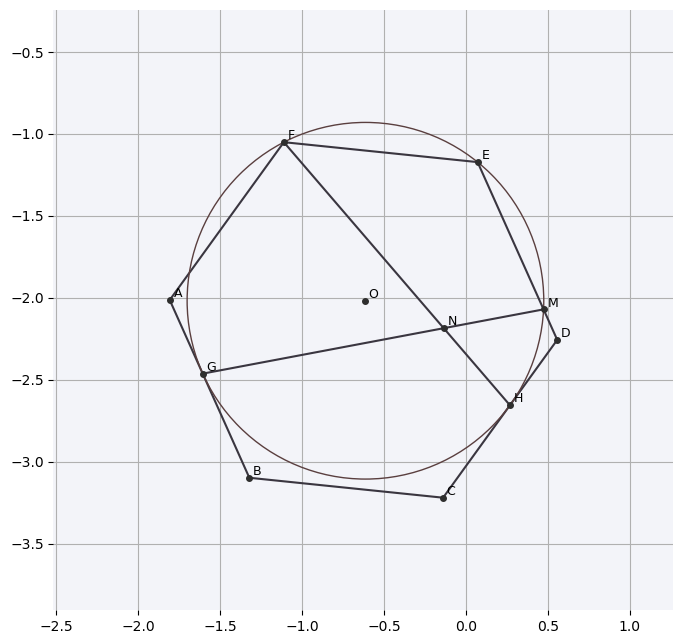

In [6]:
from pygeox import GeoScene, LineSegment

scene = GeoScene(10)

A, B, C, D, E, F, G, H, M, N, O = scene.add.points(["A", "B", "C", "D", "E", "F", "G", "H", "M", "N", "O"])

# 在正六边形 ABCDEF 中; In a regular hexagon ABCDEF
hexagon = scene.add.regular_hexagon(A, B, C, D, E, F)

# 经过点 E，F 的⊙O; a circle ⊙O passing through points E and F
circle = scene.add.circle(O)
scene.relate.points_lie_on([E, F], circle)

# CD 分别相切于点 G，H; tangent to sides AB and CD at points G and H
scene.relate.tangent_to_circle(LineSegment(A,B), circle, G)
scene.relate.tangent_to_circle(LineSegment(C,D), circle, H)

## 与边 DE 交于点 M, intersects side DE at point M
scene.relate.line_intersects_circle_at(LineSegment(D,E), circle, M)

## 连接 GM，FH 交于点 N; Lines GM and FH intersect at point N
Line_GM = scene.add.line_segment(G, M)
Line_FH = scene.add.line_segment(F, H)
scene.relate.lines_intersect_at(Line_GM, Line_FH, N)

scene.solver.numerical()
scene.plot()

In [7]:
#no copy feature
circle_r = {str(val.center.name):val.radius for val in scene.objects_solved["Circle"].values()}
scene.solver._internal_sol  - scene.solver.get_internal_vals(scene.get_points(),circle_r)

['RegularHexagon_A_B_C_D_E_F_center_x', 'RegularHexagon_A_B_C_D_E_F_center_y', 'RegularHexagon_A_B_C_D_E_F_circumradius', 'RegularHexagon_A_B_C_D_E_F_orientation', 'G_x', 'G_y', 'H_x', 'H_y', 'M_x', 'M_y', 'N_x', 'N_y', 'O_x', 'O_y', 'O_r']
['G_x', 'G_y', 'H_x', 'H_y', 'M_x', 'M_y', 'N_x', 'N_y', 'O_x', 'O_y', 'O_r', 'RegularHexagon_A_B_C_D_E_F_center_x', 'RegularHexagon_A_B_C_D_E_F_center_y', 'RegularHexagon_A_B_C_D_E_F_circumradius', 'RegularHexagon_A_B_C_D_E_F_orientation']


array([0.00000000e+00, 0.00000000e+00, 2.22044605e-16, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [5]:
scene.angle(G,N,F).evalf(4)

60.00

# Example 3
CN: 如图，在△ABC中，AB=AC=5，BC=6，点P是△ABC内一点，过点P作PD⊥AB，PE⊥BC，PF⊥AC，垂足分别为D，E，F，连接AP。若PE^2=PD\\cdot PF，则AP的最小值为___。
  
EN: 16. As shown in the figure, in triangle △ABC, AB = AC = 5, and BC = 6. Point P is an interior point of △ABC. From point P, draw perpendiculars: PD ⊥ AB, PE ⊥ BC, and PF ⊥ AC, with the feet of the perpendiculars being points D, E, and F respectively. Connect point A to point P.
Given that PE² = PD × PF, the minimum value of AP is ___.

[INFO] Object with name LineSegment_A_B already exists in scene. Passing a pointer to the existing object.
[INFO] Object with name LineSegment_B_C already exists in scene. Passing a pointer to the existing object.
[INFO] Penalty active to prevent overlapping points (min_dist=1.0). To remove add: distance_penalty = 0
Objective function value: 4.7122e-14 | Status: success

Equality constraints (should be ≈ 0):
--------------------------------------------------------------------------------------
Name                                     Equation                              Value   
--------------------------------------------------------------------------------------
sqrt((A_x - B_x)**2 + (A_y - B_y)**2) == sqrt((A_x - B_x)**2 + (A_y - B   4.5776e-08  ✅
sqrt((A_x - B_x)**2 + (A_y - B_y)**2) == sqrt((A_x - B_x)**2 + (A_y - B   4.5776e-08  ✅
sqrt((B_x - C_x)**2 + (B_y - C_y)**2) == sqrt((B_x - C_x)**2 + (B_y - C  -6.1691e-09  ✅
LineSegment_P_D ⟂ LineSegment_A_B (dot p (-A_x + B_x)*(D_x - P

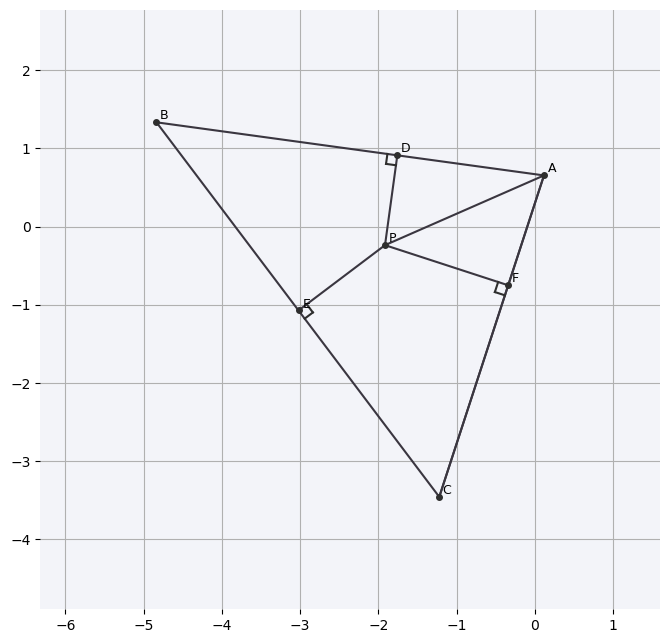

In [8]:
from pygeox import GeoScene, LineSegment

scene = GeoScene()

A, B, C, D, E, F, P = scene.add.points(["A", "B", "C", "D", "E", "F", "P"])

# In triangle △ABC, AB = AC = 5, and BC = 6
triangle = scene.add.triangle(A, B, C)
scene.constraint.eq(LineSegment(A,B).length, 5)
scene.constraint.eq(LineSegment(A,B).length, 5)
scene.constraint.eq(LineSegment(B,C).length, 6)

# Point P is an interior point of △ABC
scene.relate.inside(P, triangle)

# From point P, draw perpendiculars: PD ⊥ AB, PE ⊥ BC, and PF ⊥ AC, with the feet of the perpendiculars being points D, E, and F respectively
line_PD = scene.add.line_segment(P,D)
line_AB = scene.add.line_segment(A,B)
line_PE = scene.add.line_segment(P,E)
line_BC = scene.add.line_segment(B,C)
line_PF = scene.add.line_segment(P,F)
line_AC = scene.add.line_segment(A,C)
scene.relate.perpendicular(line_PD, line_AB, foot = D)
scene.relate.perpendicular(line_PE, line_BC, foot = E)
scene.relate.perpendicular(line_PF, line_AC, foot = F)

## Connect point A to point P
line_AP = scene.add.line_segment(A,P)

## Given that PE² = PD × PF
scene.constraint.eq(line_PE.length**2, line_PF.length*line_PD.length)

scene.solver.numerical()
scene.plot()

In [9]:
#no copy feature
circle_r = {str(val.center.name):val.radius for val in scene.objects_solved["Circle"].values()}
scene.solver._internal_sol  - scene.solver.get_internal_vals(scene.get_points(),circle_r)

['A_x', 'A_y', 'B_x', 'B_y', 'C_x', 'C_y', 'D_x', 'D_y', 'E_x', 'E_y', 'F_x', 'F_y', 'P_x', 'P_y']
['A_x', 'A_y', 'B_x', 'B_y', 'C_x', 'C_y', 'D_x', 'D_y', 'E_x', 'E_y', 'F_x', 'F_y', 'P_x', 'P_y']


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

# Example 4
CH: 如图，AB，CD 分别垂直 BD，垂足分别为 B，D，连接 AD，BC 交于点 E，作 EF⊥BD，垂足为 F。设 AB=a，CD=b，EF=c，若 $$\frac{b}{a} - \frac{a}{b} = 1,$$则下列等式：① a + c = b；② b + c = 2a；③ $a^2 = b \cdot c$，其中一定成立的是（ ）[A. ①②\nB. ①③\nC. ②③\nD. ①②③]

EN: As shown in the figure, lines AB and CD are perpendicular to BD, with their feet at points B and D, respectively. Connect AD and BC, which intersect at point E. Draw EF ⊥ BD, with the foot of the perpendicular at point F. Let AB = *a*, CD = *b*, and EF = *c*. Given that: $$\frac{b}{a} - \frac{a}{b} = 1,$$ which of the following equations must be true? ① $a + c = b$ ② $b + c = 2a$ ③ $a^2 = b \cdot c$ [A. ①②  B. ①③  C. ②③  D. ①②③]

[INFO] Penalty active to prevent overlapping points (min_dist=1.0). To remove add: distance_penalty = 0
Objective function value: 1.6754e-11 | Status: success

Equality constraints (should be ≈ 0):
--------------------------------------------------------------------------------------
Name                                     Equation                              Value   
--------------------------------------------------------------------------------------
LineSegment_A_B ⟂ LineSegment_B_D (dot p (-A_x + B_x)*(-B_x + D_x) + (-  -1.3130e-07  ✅
LineSegment_C_D ⟂ LineSegment_B_D (dot p (-B_x + D_x)*(-C_x + D_x) + (-  -1.4343e-06  ✅
E collinear with LineSegment_A_D         (-A_x + D_x)*(-A_y + E_y) - (-   1.9822e-06  ✅
E collinear with LineSegment_B_C         (-B_x + C_x)*(-B_y + E_y) - (-  -2.5344e-07  ✅
LineSegment_E_F ⟂ LineSegment_B_D (dot p (-B_x + D_x)*(-E_x + F_x) + (-   2.4569e-07  ✅
F collinear with LineSegment_B_D         (-B_x + D_x)*(-B_y + F_y) - (-   1.3188e-06  ✅
AB = a      

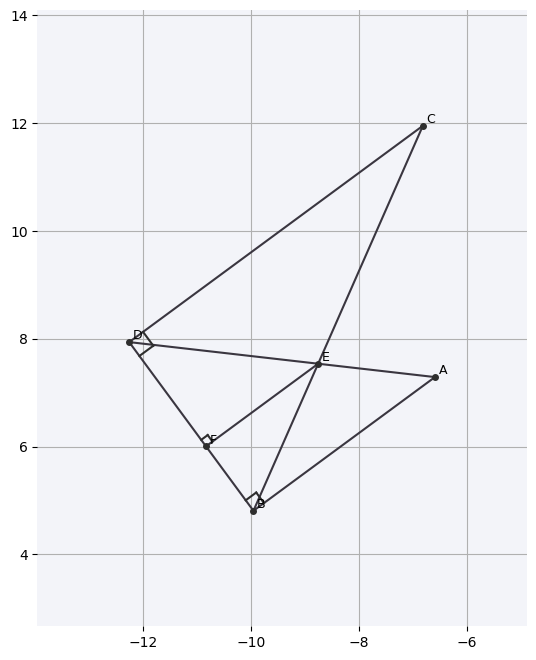

In [10]:
from pygeox import GeoScene, LineSegment
from sympy import Symbol

scene = GeoScene()

A, B, C, D, E, F = scene.add.points(["A", "B", "C", "D", "E", "F"])

# lines AB and CD are perpendicular to BD, with their feet at points B and D, respectively
line_AB = scene.add.line_segment(A,B)
line_CD = scene.add.line_segment(C,D)
line_BD = scene.add.line_segment(B,D)
scene.relate.perpendicular(line_AB, line_BD, foot = B)
scene.relate.perpendicular(line_CD, line_BD, foot = D)

# Connect AD and BC, which intersect at point E.
line_AD = scene.add.line_segment(A,D)
line_BC = scene.add.line_segment(B,C)
scene.relate.lines_intersect_at(line_AD, line_BC, E)

# Draw EF ⊥ BD, with the foot of the perpendicular at point F
line_EF = scene.add.line_segment(E,F)
scene.relate.perpendicular(line_EF, line_BD, foot = F)

## Let AB = a, CD = b, and EF = c
a,b,c = Symbol("a"), Symbol("b"), Symbol("c")
[scene.add_parameter(s) for s in [a,b,c]]
scene.constraint.eq(line_AB.length, a, "AB = a")
scene.constraint.eq(line_CD.length, b, "CD = b")
scene.constraint.eq(line_EF.length, c, "EF = c")

## \frac{b}{a} - \frac{a}{b} = 1
scene.constraint.eq(b/a-a/b, 1)

scene.solver.numerical()
scene.plot()

# Example 5
CH: 如图，正八边形 ABCDEFGH 的对角线 AF，HD 交于点 M，则∠AMH 的度数是 ___°

EN: As shown in the figure, in regular octagon ABCDEFGH, the diagonals AF and HD intersect at point M. What is the measure of ∠AMH?

In [19]:
from pygeox import GeoScene, LineSegment
from sympy import Symbol

scene = GeoScene()

A, B, C, D, E, F, G, H, M = scene.add.points(["A", "B", "C", "D", "E", "F", "G", "H", "M"])

# octagon ABCDEFGH
scene.add.regular_octagon(A, B, C, D, E, F, G, H)

# the diagonals AF and HD intersect at point M
line_AF = scene.add.line_segment(A,F)
line_HD = scene.add.line_segment(H,D)
scene.relate.lines_intersect_at(line_AF, line_HD, M)

scene.solver.numerical(distance_penalty=0.01)
scene.plot()

[INFO] Penalty active to prevent overlapping points (min_dist=1.0). To remove add: distance_penalty = 0
Objective function value: 1.0201e-04 | Status: failure

Equality constraints (should be ≈ 0):
--------------------------------------------------------------------------------------
Name                                     Equation                              Value   
--------------------------------------------------------------------------------------
M collinear with LineSegment_A_F         -(-RegularOctagon_A_B_C_D_E_F_   0.0000e+00  ✅
M collinear with LineSegment_H_D         -2*RegularOctagon_A_B_C_D_E_F_  -0.0000e+00  ✅

Inequality constraints (should be ≥ 0):
--------------------------------------------------------------------------------------
Name                                     Equation                              Value   
--------------------------------------------------------------------------------------
M is after A along LineSegment_A_F       (-RegularOctagon_A_B

ValueError: Geometry constraint solving failed. Please obtain a valid solution with solver.solve

In [11]:
scene.angle(A,M,H).evalf(4)

67.50